In [15]:
#!/usr/bin/env python3
"""
==============================================================================
CONNECTIVITY VALIDATION  (haor_connectivity_validation.ipynb)
==============================================================================
A standalone notebook answering three questions raised after the seminar.
It reads only files your existing pipeline already wrote, so nothing here
requires re-running haor_flood_hydroyear.ipynb.

PART A   Is the connectivity switching real, or an artefact of satellite
         coverage?  (Prof. Yamazaki: "Do they really connect and disconnect
         many times in a year, or once continuously?")
         Four independent tests, all from CSVs.

PART B   Can connectivity be discussed from satellite at all?
         Reframes the result as POTENTIAL connectivity (radar sees shapes
         touching) versus ACTUAL connectivity (SWOT sees one water level),
         following the distinction Brooks et al. (2018) drew between
         potential and actual contributing area.

PART C   A real 2D map replacing the schematic on slide 14: Sentinel-1
         inundation with SWOT water levels on top, for one merged date and
         one separate date.

RUN ORDER
  1. Run Part A and Part B here. They need nothing but CSVs.
  2. Run Part C1. It writes swot_map_dates.csv.
  3. On the server, run:  python swot_extract_pixels.py
  4. Come back and run Part C2 to draw the map.
==============================================================================
"""
import os, re, glob, datetime
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import plotting_extent
from scipy.stats import mannwhitneyu
print("\u2713 imports ok")


✓ imports ok


In [16]:
# %%
# ============================ PATHS & SETTINGS ============================
BASE          = "/work/a06/wasif/haor_flood_analysis_hydroyear"
ANALYSIS_ROOT = os.path.join(BASE, "analysis")
HAORS_SHP     = "/work/a06/wasif/haor_flood_analysis/digitization/haors_manual.shp"

# SWOT products. The per-haor medians live in the OLD multiyear folder; the
# pair validation table is written by the hydro-year notebook.
SWOT_PERHAOR = "/work/a06/wasif/haor_flood_analysis_multiyear/analysis/swot_perhaor_wse.csv"
SWOT_PAIRS   = os.path.join(ANALYSIS_ROOT, "swot_pair_validation.csv")
SWOT_PIXELS  = os.path.join(ANALYSIS_ROOT, "swot_pixels")

# ---- test settings ----
STRICT_COVERAGE = 0.90   # Part A4: keep only dates where this much of the cluster was seen
LEVEL_TOL       = 0.15   # Part B: two basins count as "same level" within this many metres
TOL_SWEEP       = [0.10, 0.15, 0.20]   # Part B sensitivity
MATCH_DAYS      = 3      # Part C: SWOT pass must be within this many days of the radar date

CENTRAL_HAOR = "GMA"
HAOR_COLORS  = {"GMA":"#E07856","TGR":"#1C7293","HLR":"#0F766E",
                "SHN":"#7C3AED","MTN":"#0A2540"}

YEARS = sorted(int(re.search(r"(\d{4})", os.path.basename(f)).group(1))
               for f in glob.glob(os.path.join(BASE, "flood_stack_cluster_*.tif")))
assert YEARS, f"no flood_stack_cluster_<year>.tif found in {BASE}"
print("years:", YEARS)

os.environ["SHAPE_RESTORE_SHX"] = "YES"
haors = gpd.read_file(HAORS_SHP)
haors = haors[haors["haor_id"] != "DUMMY"].copy()
HAOR_IDS = haors["haor_id"].tolist()
print("haors:", HAOR_IDS)

def yr_dir(y): return os.path.join(ANALYSIS_ROOT, str(y))
def doy_to_date(y, doy):
    """Day index counts from 1 Jan of the ANALYSIS year, so values above 365
    correctly roll into the following calendar year."""
    return datetime.date(int(y), 1, 1) + datetime.timedelta(days=float(doy))

# load every year's connectivity curve and connection matrix once
conn, mats, curves = {}, {}, {}
for y in YEARS:
    c = os.path.join(yr_dir(y), f"connectivity_curve_{y}.csv")
    m = os.path.join(yr_dir(y), f"haor_connection_matrix_{y}.csv")
    h = os.path.join(yr_dir(y), f"haor_hydrograph_curves_{y}.csv")
    if not (os.path.exists(c) and os.path.exists(m)):
        print(f"  [{y}] connectivity files missing, skipped"); continue
    conn[y]   = pd.read_csv(c)
    mats[y]   = pd.read_csv(m)
    curves[y] = pd.read_csv(h) if os.path.exists(h) else None
print(f"loaded {len(conn)} years of connectivity output")


years: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
haors: ['MTN', 'SHN', 'HLR', 'TGR', 'GMA']
loaded 7 years of connectivity output


In [17]:
# %%
# ================= PART A1: does coverage drive the connectivity state? =================
# If the switching were an artefact, dates where the satellite saw less of the
# cluster would show fewer connected basins. We test that directly by comparing
# the observed fraction on dates that reported all five merged against dates
# that did not.
rows = []
for y, d in conn.items():
    v = d[d["n_components"] >= 0].copy()          # drop the guard-skipped dates
    if not len(v): continue
    a = v.loc[v["all_connected"] == True,  "obs_raw"]
    b = v.loc[v["all_connected"] == False, "obs_raw"]
    if len(a) > 3 and len(b) > 3:
        u, p = mannwhitneyu(a, b, alternative="two-sided")
    else:
        p = np.nan
    rows.append(dict(year=y, n_merged=len(a), n_sep=len(b),
                     cov_merged=round(a.mean(), 4) if len(a) else np.nan,
                     cov_separate=round(b.mean(), 4) if len(b) else np.nan,
                     diff=round((a.mean() - b.mean()), 4) if (len(a) and len(b)) else np.nan,
                     p=p))
A1 = pd.DataFrame(rows)
print("Mean observed fraction of the cluster, merged dates vs the rest\n")
print(A1.to_string(index=False))

sig = A1[(A1["p"] < 0.05) & (A1["diff"] > 0.02)]
print("\nReading:")
print("  If cov_merged is much HIGHER than cov_separate, coverage is helping to")
print("  create the merged state, which would support the artefact explanation.")
print("  If the two are close, the state is not being driven by how much was seen.")
print(f"\n  years where merged dates had meaningfully better coverage: "
      f"{sig['year'].tolist() if len(sig) else 'none'}")


Mean observed fraction of the cluster, merged dates vs the rest

 year  n_merged  n_sep  cov_merged  cov_separate    diff            p
 2019        18     93      0.9296        0.9815 -0.0519 1.886477e-08
 2020        27     97      0.9609        0.9877 -0.0268 1.325334e-04
 2021        13    105      0.9631        0.9878 -0.0248 2.428768e-04
 2022        16    100      0.9386        0.9856 -0.0470 1.720904e-05
 2023        12    101      0.9504        0.9831 -0.0327 6.742543e-04
 2024        11     97      0.8878        0.9809 -0.0931 3.382320e-07
 2025         5    111      0.9606        0.9801 -0.0195 2.043167e-02

Reading:
  If cov_merged is much HIGHER than cov_separate, coverage is helping to
  create the merged state, which would support the artefact explanation.
  If the two are close, the state is not being driven by how much was seen.

  years where merged dates had meaningfully better coverage: none


Cluster flooded fraction on merged vs separate dates (median)

 year  n_merged  n_sep  frac_merged  frac_separate            p
 2019        18     93        0.812          0.275 6.804528e-11
 2020        27     97        0.877          0.206 3.144577e-15
 2021        13    105        0.829          0.189 1.984030e-08
 2022        16    100        0.860          0.364 8.894088e-10
 2023        12    101        0.850          0.029 2.303928e-08
 2024        11     97        0.865          0.162 3.862842e-08
 2025         5    111        0.812          0.363 7.207829e-04

pooled across years: merged median 0.850 (n=102), separate median 0.232 (n=704), Mann-Whitney p = 3.00e-53
best separating flooded fraction: 0.80  (classifies 93% of dates correctly)


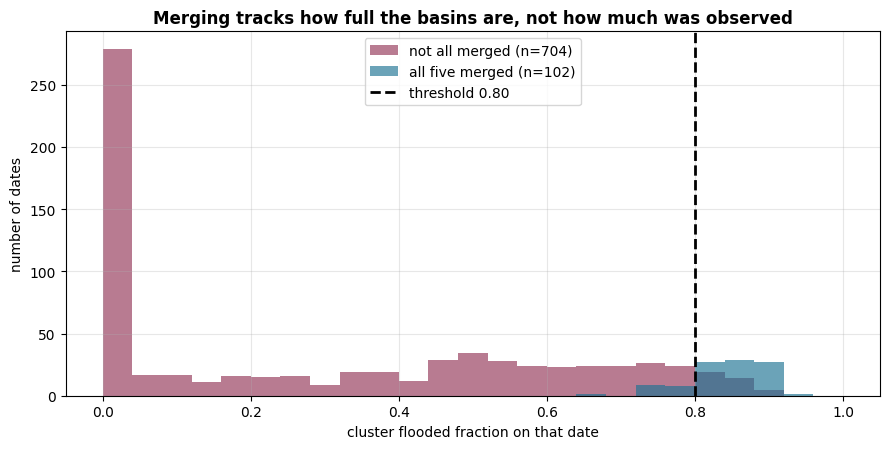

In [18]:
# %%
# ================= PART A2: is merging controlled by water level? =================
# A physical, threshold-controlled system should merge when the basins are full
# and separate when they are not. We compare the cluster-average flooded
# fraction on merged dates against separate dates. Clear separation means the
# state tracks water, not sampling.
rows, pooled = [], []
for y in conn:
    if curves.get(y) is None: continue
    cur = curves[y].copy()
    cur["cluster_frac"] = cur[HAOR_IDS].mean(axis=1)
    v = conn[y][conn[y]["n_components"] >= 0][["doy", "all_connected", "obs_raw"]]
    j = v.merge(cur[["doy", "cluster_frac"]], on="doy", how="inner").dropna()
    if not len(j): continue
    a = j.loc[j["all_connected"] == True,  "cluster_frac"]
    b = j.loc[j["all_connected"] == False, "cluster_frac"]
    if len(a) > 3 and len(b) > 3:
        u, p = mannwhitneyu(a, b, alternative="greater")
    else:
        p = np.nan
    rows.append(dict(year=y, n_merged=len(a), n_sep=len(b),
                     frac_merged=round(a.median(), 3) if len(a) else np.nan,
                     frac_separate=round(b.median(), 3) if len(b) else np.nan,
                     p=p))
    j["year"] = y; pooled.append(j)
A2 = pd.DataFrame(rows)
POOL = pd.concat(pooled, ignore_index=True) if pooled else pd.DataFrame()
print("Cluster flooded fraction on merged vs separate dates (median)\n")
print(A2.to_string(index=False))

if len(POOL):
    a = POOL.loc[POOL["all_connected"] == True,  "cluster_frac"]
    b = POOL.loc[POOL["all_connected"] == False, "cluster_frac"]
    u, p = mannwhitneyu(a, b, alternative="greater")
    print(f"\npooled across years: merged median {a.median():.3f} (n={len(a)}), "
          f"separate median {b.median():.3f} (n={len(b)}), Mann-Whitney p = {p:.2e}")
    # the crossover level: the fraction that best separates the two states
    grid = np.linspace(0.05, 0.95, 181)
    acc = [( (a >= t).sum() + (b < t).sum() ) / (len(a) + len(b)) for t in grid]
    t_best = float(grid[int(np.argmax(acc))])
    print(f"best separating flooded fraction: {t_best:.2f}  "
          f"(classifies {max(acc)*100:.0f}% of dates correctly)")

    fig, ax = plt.subplots(figsize=(9, 4.6))
    bins = np.linspace(0, 1, 26)
    ax.hist(b, bins=bins, alpha=.65, label=f"not all merged (n={len(b)})", color="#933556")
    ax.hist(a, bins=bins, alpha=.65, label=f"all five merged (n={len(a)})", color="#1C7293")
    ax.axvline(t_best, color="k", ls="--", lw=2, label=f"threshold {t_best:.2f}")
    ax.set_xlabel("cluster flooded fraction on that date")
    ax.set_ylabel("number of dates"); ax.legend(); ax.grid(alpha=.3)
    ax.set_title("Merging tracks how full the basins are, not how much was observed",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYSIS_ROOT, "A2_threshold_test.png"), dpi=160)
    plt.show()


Merge episodes per year

 year  episodes  longest_obs  longest_span_days  median_span_days  first_merge  last_merge  window_days
 2019        10            5               15.0               0.0        163.0       307.0        144.0
 2020        16            3                5.0               0.0        158.0       314.0        156.0
 2021        11            2                3.0               0.0        171.0       293.0        122.0
 2022        12            3                5.0               0.0        142.0       303.0        161.0
 2023         9            2                5.0               0.0        173.0       298.0        125.0
 2024         9            2                3.0               0.0        161.0       293.0        132.0
 2025         4            2                3.0               0.0        157.0       217.0         60.0

Reading:
  episodes = number of separate spells during which all five were one body
  window_days = first to last merged date, the outer booke

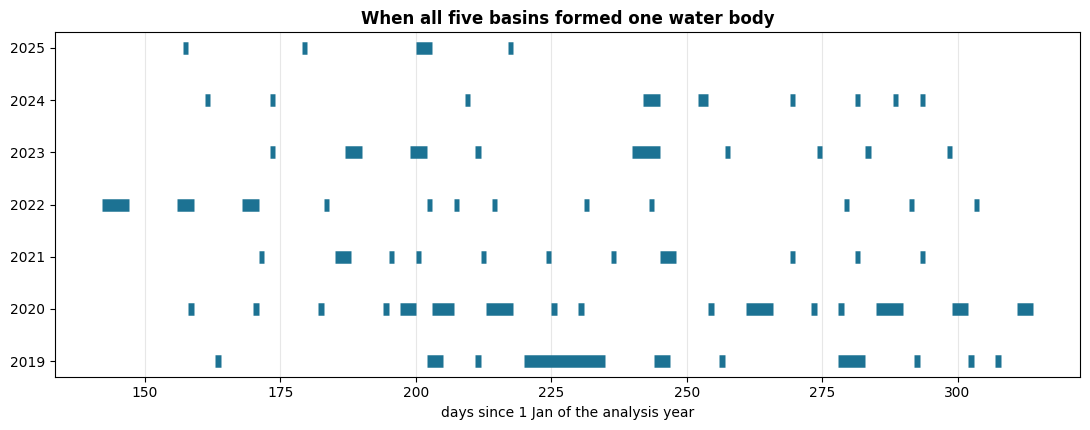

In [19]:
# %%
# ================= PART A3: how many merge episodes per year? =================
# This answers the question as it was actually asked: do the basins connect and
# disconnect repeatedly, or connect once and stay connected? We count runs of
# consecutive merged observations and measure how long each lasts.
def episodes(df):
    """Return a list of (start_doy, end_doy, n_obs) for each run of merged dates."""
    v = df[df["n_components"] >= 0].sort_values("doy")
    out, run = [], []
    for _, r in v.iterrows():
        if r["all_connected"]:
            run.append(r["doy"])
        elif run:
            out.append((run[0], run[-1], len(run))); run = []
    if run: out.append((run[0], run[-1], len(run)))
    return out

rows = []
for y in sorted(conn):
    ep = episodes(conn[y])
    if not ep:
        rows.append(dict(year=y, episodes=0)); continue
    spans = [e[1] - e[0] for e in ep]
    rows.append(dict(year=y, episodes=len(ep),
                     longest_obs=max(e[2] for e in ep),
                     longest_span_days=round(max(spans), 0),
                     median_span_days=round(float(np.median(spans)), 0),
                     first_merge=round(ep[0][0], 0), last_merge=round(ep[-1][1], 0),
                     window_days=round(ep[-1][1] - ep[0][0], 0)))
A3 = pd.DataFrame(rows)
print("Merge episodes per year\n")
print(A3.to_string(index=False))
print("\nReading:")
print("  episodes = number of separate spells during which all five were one body")
print("  window_days = first to last merged date, the outer bookends")
print("  Many short episodes inside a long window means the system genuinely")
print("  switches. One long episode would mean it connects once and stays.")

fig, ax = plt.subplots(figsize=(11, 4.4))
for i, y in enumerate(sorted(conn)):
    for (s, e, n) in episodes(conn[y]):
        ax.plot([s, max(e, s + 1)], [y, y], lw=9, solid_capstyle="butt", color="#1C7293")
ax.set_yticks(sorted(conn)); ax.set_xlabel("days since 1 Jan of the analysis year")
ax.set_title("When all five basins formed one water body", fontweight="bold")
ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.savefig(os.path.join(ANALYSIS_ROOT, "A3_episodes.png"), dpi=160)
plt.show()


In [20]:
# %%
# ================= PART A4: does the switching survive strict coverage? =================
# Raising the coverage guard only REMOVES dates; it never changes the state that
# was computed for a date that passes. So subsetting the existing table at
# obs_raw >= STRICT_COVERAGE is exactly equivalent to re-running the whole
# pipeline with MIN_OBSERVED_FRAC set that high, at no computational cost.
rows = []
for y in sorted(conn):
    v = conn[y][conn[y]["n_components"] >= 0]
    s = v[v["obs_raw"] >= STRICT_COVERAGE]
    def stats(df):
        if not len(df): return (0, np.nan, 0)
        ep = episodes(df)
        return (len(df), round(df["all_connected"].mean(), 3), len(ep))
    n0, f0, e0 = stats(v)
    n1, f1, e1 = stats(s)
    rows.append(dict(year=y, dates_all=n0, merged_frac_all=f0, episodes_all=e0,
                     dates_strict=n1, merged_frac_strict=f1, episodes_strict=e1,
                     dates_kept=f"{100*n1/max(n0,1):.0f}%"))
A4 = pd.DataFrame(rows)
print(f"Connectivity using every scored date, versus only dates where at least "
      f"{STRICT_COVERAGE:.0%} of the cluster was observed\n")
print(A4.to_string(index=False))

d = (A4["merged_frac_strict"] - A4["merged_frac_all"]).dropna()
print("\nReading:")
print("  If merged_frac_strict is close to merged_frac_all, the merged state is")
print("  not an artefact of poorly observed dates.")
print(f"  mean change in merged fraction: {d.mean():+.3f}")
print(f"  episodes still present under strict coverage in "
      f"{(A4['episodes_strict'] > 1).sum()} of {len(A4)} years")


Connectivity using every scored date, versus only dates where at least 90% of the cluster was observed

 year  dates_all  merged_frac_all  episodes_all  dates_strict  merged_frac_strict  episodes_strict dates_kept
 2019        111            0.162            10           106               0.142                9        95%
 2020        124            0.218            16           121               0.198               14        98%
 2021        118            0.110            11           117               0.103               11        99%
 2022        116            0.138            12           113               0.115               11        97%
 2023        113            0.106             9           110               0.091                7        97%
 2024        108            0.102             9           102               0.059                5        94%
 2025        116            0.043             4           111               0.045                4        96%

Reading:
  If m

In [21]:
# %%
# ================= PART A: verdict =================
# Direction matters in A1. The artefact hypothesis says coverage CREATES the
# merged state, which requires merged dates to have BETTER coverage. A negative
# difference means merged dates were observed slightly less well, which is the
# opposite of the artefact and therefore supports the physical reading.
print("=" * 76)
print("IS THE CONNECTIVITY SWITCHING REAL?")
print("=" * 76)
ev = []

if len(A1):
    i = A1["diff"].abs().idxmax()
    worst = float(A1.loc[i, "diff"])          # signed, not absolute
    n_better = int((A1["diff"] > 0).sum())
    direction = "BETTER" if worst > 0 else "WORSE"
    ev.append((
        "A1 coverage",
        f"merged dates had {direction} coverage than the rest, largest gap "
        f"{abs(worst):.3f} (year {int(A1.loc[i,'year'])}); "
        f"{n_better} of {len(A1)} years had better coverage on merged dates",
        worst <= 0.02,
        "an artefact would need merged dates to be BETTER observed, not worse"))

if len(POOL):
    a = POOL.loc[POOL.all_connected == True,  "cluster_frac"]
    b = POOL.loc[POOL.all_connected == False, "cluster_frac"]
    u, p = mannwhitneyu(a, b, alternative="greater")
    ev.append((
        "A2 water level",
        f"merged dates are fuller: {a.median():.3f} vs {b.median():.3f}, p = {p:.1e}",
        p < 0.01,
        "merging tracks how full the basins are, which is threshold behaviour"))

if len(A3):
    multi = int((A3["episodes"] > 1).sum())
    med_ep = float(A3["episodes"].median())
    ev.append((
        "A3 episodes",
        f"{multi} of {len(A3)} years show more than one merge episode, "
        f"median {med_ep:.0f} episodes per year",
        multi == len(A3),
        "repeated switching, not a single continuous connection"))

if len(A4):
    d = float((A4["merged_frac_strict"] - A4["merged_frac_all"]).mean())
    still = int((A4["episodes_strict"] > 1).sum())
    ev.append((
        "A4 strict coverage",
        f"merged fraction changes by {d:+.3f} when only well observed dates are "
        f"kept; multiple episodes survive in {still} of {len(A4)} years",
        abs(d) < 0.10,
        "the state does not depend on poorly observed dates"))

for name, msg, ok, why in ev:
    tag = "supports physical" if ok else "CHECK"
    print(f"\n  [{tag}]  {name}")
    print(f"      {msg}")
    print(f"      why this matters: {why}")

n_ok = sum(1 for *_, ok, _ in ev if ok)
print("\n" + "-" * 76)
print(f"  {n_ok} of {len(ev)} tests support a physical interpretation.")
if n_ok == len(ev):
    print("""
  The claim you can defend:

    The five basins merge only when the cluster is close to fully flooded,
    around 80 percent, and the merged state recurs in short episodes across a
    months long window in every year. It is not produced by satellite coverage:
    merged dates were observed slightly LESS completely than other dates, and
    unobserved pixels can only break a connection, never create one.

  The limit to state honestly:

    At a four day revisit, and with a detector sensitive to wind roughening of
    the water surface, individual short episodes cannot be separated from
    threshold crossings caused by measurement noise. The robust claims are that
    merging requires high water, that it recurs every year, and that it is not
    a coverage artefact.""")
else:
    print("  At least one test did not support the physical reading. Read the")
    print("  CHECK line above before writing any conclusion.")

IS THE CONNECTIVITY SWITCHING REAL?

  [supports physical]  A1 coverage
      merged dates had WORSE coverage than the rest, largest gap 0.093 (year 2024); 0 of 7 years had better coverage on merged dates
      why this matters: an artefact would need merged dates to be BETTER observed, not worse

  [supports physical]  A2 water level
      merged dates are fuller: 0.850 vs 0.232, p = 3.0e-53
      why this matters: merging tracks how full the basins are, which is threshold behaviour

  [supports physical]  A3 episodes
      7 of 7 years show more than one merge episode, median 10 episodes per year
      why this matters: repeated switching, not a single continuous connection

  [supports physical]  A4 strict coverage
      merged fraction changes by -0.018 when only well observed dates are kept; multiple episodes survive in 7 of 7 years
      why this matters: the state does not depend on poorly observed dates

--------------------------------------------------------------------------

In [22]:
# %%
# ================= PART B: potential connectivity versus actual =================
# Radar sees geometry: two basins whose flood extents touch. That is POTENTIAL
# connectivity. SWOT sees water level: connected water must equilibrate, so
# equal levels are evidence of ACTUAL hydraulic connection. Brooks et al. (2018)
# drew the same distinction in the Prairie Pothole Region, using isotopes for
# the actual side; here a second satellite does that job.
assert os.path.exists(SWOT_PAIRS), (
    f"missing {SWOT_PAIRS}. Run the SWOT validation cell in "
    "haor_flood_hydroyear.ipynb first.")
pairs = pd.read_csv(SWOT_PAIRS)
ycol = "analysis_year" if "analysis_year" in pairs.columns else "year"
print(f"{len(pairs)} pair observations, {pairs[ycol].nunique()} years, "
      f"{pairs['doy'].nunique()} distinct dates")

# adjacency, verified from the digitized geometry
ADJACENT = {"GMA-TGR","TGR-GMA","GMA-MTN","MTN-GMA","GMA-HLR","HLR-GMA",
            "GMA-SHN","SHN-GMA","TGR-MTN","MTN-TGR","HLR-SHN","SHN-HLR",
            "MTN-SHN","SHN-MTN"}
pairs["adjacency"] = np.where(pairs["pair"].isin(ADJACENT), "adjacent", "indirect")

def classify(df, tol):
    """Label every pair observation by what the radar said and what SWOT found.
    np.select needs an explicit string default under numpy 2, otherwise it tries
    to reconcile the integer 0 with the string choices and raises a TypeError."""
    d = df.copy()
    d["same_level"] = d["dwse"] <= tol
    d["class"] = np.select(
        [ (d.state == "merged")   &  d.same_level,
          (d.state == "merged")   & ~d.same_level,
          (d.state == "separate") &  d.same_level,
          (d.state == "separate") & ~d.same_level ],
        ["confirmed connected", "touching but not level",
         "apart but level alike", "confirmed separate"],
        default="unclassified")
    return d

P = classify(pairs, LEVEL_TOL)
if (P["class"] == "unclassified").any():
    n = int((P["class"] == "unclassified").sum())
    print(f"\n  warning: {n} rows fell outside the four categories. "
          f"Check the 'state' column for values other than merged and separate.")

# Build the 2x2 explicitly. Using crosstab here would silently mislabel the
# columns if every pair happened to land on one side of the tolerance, because
# the column order depends on which values are present.
def counts(df, tol):
    rows = []
    for st in ["merged", "separate"]:
        g = df[df["state"] == st]
        same = int((g["dwse"] <= tol).sum())
        diff = int(len(g) - same)
        rows.append({"radar says": st, f"same level (<= {tol} m)": same,
                     f"level differs (> {tol} m)": diff, "total": len(g),
                     "share same level": f"{100*same/len(g):.0f}%" if len(g) else "n/a"})
    return pd.DataFrame(rows)

print(f"\nPotential versus actual, level tolerance {LEVEL_TOL} m\n")
print(counts(P, LEVEL_TOL).to_string(index=False))

m = P[P.state == "merged"]
if len(m):
    conf = (m["dwse"] <= LEVEL_TOL).mean()
    print(f"\nOf pairs the radar calls MERGED, {100*conf:.0f}% also share a water "
          f"level within {LEVEL_TOL} m.")
    print("That is the fraction of potential connections confirmed as actual.")
    for adj, g in m.groupby("adjacency"):
        print(f"   {adj:9}: {100*(g['dwse'] <= LEVEL_TOL).mean():.0f}% confirmed  (n = {len(g)})")

print("\nCaution on the other row: pairs the radar calls SEPARATE that happen to")
print("sit at a similar level are NOT evidence of a hidden connection. At high")
print("water the same regional flood fills every basin to a similar depth, so")
print("levels agree whether or not the basins are joined. Only the merged rows")
print("are diagnostic.")

print(f"\nSensitivity of the confirmed fraction to the tolerance:")
for t in TOL_SWEEP:
    mm = pairs[pairs.state == "merged"]
    if len(mm):
        print(f"   tolerance {t:.2f} m: {100*(mm['dwse'] <= t).mean():.0f}% of merged pairs confirmed")

868 pair observations, 3 years, 87 distinct dates

Potential versus actual, level tolerance 0.15 m

radar says  same level (<= 0.15 m)  level differs (> 0.15 m)  total share same level
    merged                     157                        53    210              75%
  separate                     328                       330    658              50%

Of pairs the radar calls MERGED, 75% also share a water level within 0.15 m.
That is the fraction of potential connections confirmed as actual.
   adjacent : 91% confirmed  (n = 151)
   indirect : 34% confirmed  (n = 59)

Caution on the other row: pairs the radar calls SEPARATE that happen to
sit at a similar level are NOT evidence of a hidden connection. At high
water the same regional flood fills every basin to a similar depth, so
levels agree whether or not the basins are joined. Only the merged rows
are diagnostic.

Sensitivity of the confirmed fraction to the tolerance:
   tolerance 0.10 m: 47% of merged pairs confirmed
   toleranc

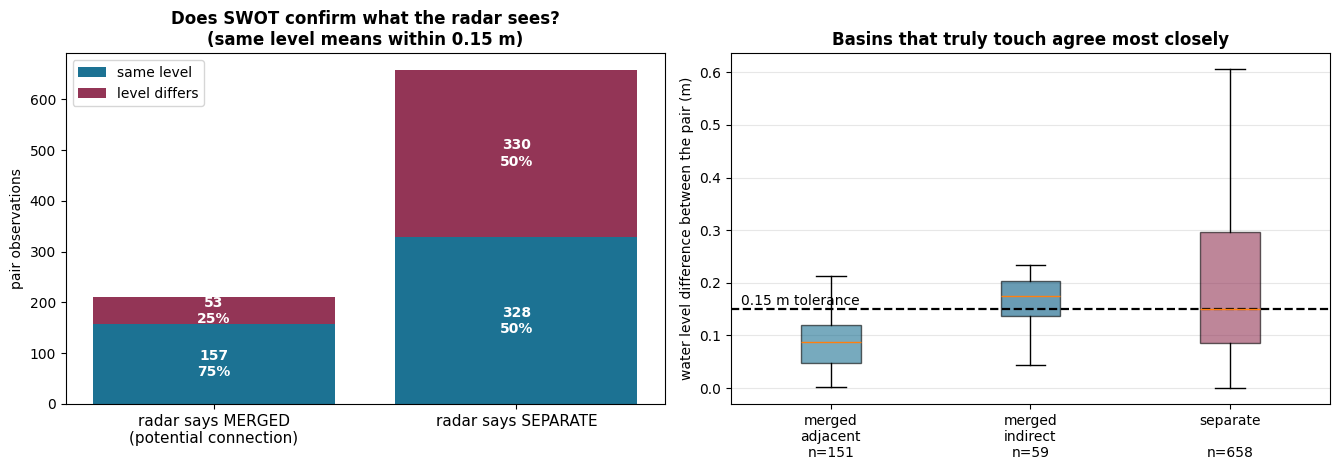

In [23]:
# %%
# ================= PART B: the figure =================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))

# left: the 2x2 as stacked bars
order = ["merged", "separate"]
conf_c, diff_c = "#1C7293", "#933556"
for i, st in enumerate(order):
    g = P[P.state == st]
    same = (g["dwse"] <= LEVEL_TOL).sum(); diff = len(g) - same
    ax[0].bar(i, same, color=conf_c, label="same level" if i == 0 else None)
    ax[0].bar(i, diff, bottom=same, color=diff_c, label="level differs" if i == 0 else None)
    ax[0].text(i, same/2, f"{same}\n{100*same/len(g):.0f}%", ha="center", va="center",
               color="white", fontweight="bold")
    ax[0].text(i, same + diff/2, f"{diff}\n{100*diff/len(g):.0f}%", ha="center",
               va="center", color="white", fontweight="bold")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["radar says MERGED\n(potential connection)",
                       "radar says SEPARATE"], fontsize=11)
ax[0].set_ylabel("pair observations"); ax[0].legend(fontsize=10)
ax[0].set_title(f"Does SWOT confirm what the radar sees?\n(same level means within {LEVEL_TOL} m)",
                fontweight="bold", fontsize=12)

# right: level difference by adjacency
groups, labels, colors = [], [], []
for st, adj, c in [("merged","adjacent","#1C7293"), ("merged","indirect","#065A82"),
                   ("separate", None, "#933556")]:
    g = P[(P.state == st)] if adj is None else P[(P.state == st) & (P.adjacency == adj)]
    if len(g) < 3: continue
    groups.append(g["dwse"].values)
    labels.append(f"merged\n{adj}\nn={len(g)}" if adj else f"separate\n\nn={len(g)}")
    colors.append(c)
bp = ax[1].boxplot(groups, tick_labels=labels, showfliers=False, patch_artist=True)
for p_, c in zip(bp["boxes"], colors): p_.set_facecolor(c); p_.set_alpha(.6)
ax[1].axhline(LEVEL_TOL, color="k", ls="--", lw=1.6)
ax[1].text(0.55, LEVEL_TOL + 0.008, f"{LEVEL_TOL} m tolerance", fontsize=10)
ax[1].set_ylabel("water level difference between the pair (m)")
ax[1].set_title("Basins that truly touch agree most closely", fontweight="bold", fontsize=12)
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_ROOT, "B_potential_vs_actual.png"), dpi=160)
plt.show()


In [24]:
# %%
# ================= PART C1: choose the dates to map =================
# We want two dates in the same year: one where the radar found all five basins
# merged, and one where it found them separate. Both must have a SWOT pass
# within MATCH_DAYS so that levels can be drawn on the same map.
assert os.path.exists(SWOT_PERHAOR), f"missing {SWOT_PERHAOR}"
sw = pd.read_csv(SWOT_PERHAOR, parse_dates=["dt"])
sw["date"] = sw["dt"].dt.date
# how many basins SWOT saw on each calendar date
swd = sw.groupby("date")["haor_id"].nunique().rename("n_haors_swot").reset_index()
print(f"SWOT dates available: {len(swd)}  "
      f"(best coverage: {swd['n_haors_swot'].max()} of 5 basins)")

cands = []
for y in sorted(conn):
    v = conn[y][conn[y]["n_components"] >= 0].copy()
    v["date"] = [doy_to_date(y, d) for d in v["doy"]]
    for _, r in v.iterrows():
        near = swd[(swd["date"] - r["date"]).abs() <= datetime.timedelta(days=MATCH_DAYS)]
        if not len(near): continue
        best = near.loc[near["n_haors_swot"].idxmax()]
        cands.append(dict(year=y, doy=r["doy"], radar_date=r["date"],
                          swot_date=best["date"], gap=abs((best["date"]-r["date"]).days),
                          n_haors_swot=int(best["n_haors_swot"]),
                          obs_raw=r["obs_raw"], all_connected=bool(r["all_connected"]),
                          largest_frac=r["largest_frac"]))
CAND = pd.DataFrame(cands)
print(f"radar dates with a SWOT pass within {MATCH_DAYS} days: {len(CAND)}")

def pick(df, merged):
    g = df[(df["all_connected"] == merged) & (df["obs_raw"] >= 0.90)]
    if not len(g): g = df[df["all_connected"] == merged]
    if not len(g): return None
    # prefer the most SWOT basins, then the smallest gap, then best coverage
    return g.sort_values(["n_haors_swot", "gap", "obs_raw"],
                         ascending=[False, True, False]).iloc[0]

best_year, chosen = None, None
for y in sorted(CAND["year"].unique()):
    sub = CAND[CAND["year"] == y]
    a, b = pick(sub, True), pick(sub, False)
    if a is None or b is None: continue
    score = a["n_haors_swot"] + b["n_haors_swot"]
    if chosen is None or score > chosen[2]:
        chosen, best_year = (a, b, score), y
assert chosen, "no year had both a merged and a separate date with SWOT nearby"
mrg, sep, _ = chosen
print(f"\nchosen year: {best_year}")
for lbl, r in [("merged", mrg), ("separate", sep)]:
    print(f"  {lbl:9}: radar {r['radar_date']} (day {r['doy']:.0f}), "
          f"SWOT {r['swot_date']} (gap {r['gap']}d), "
          f"{r['n_haors_swot']} basins seen, coverage {r['obs_raw']:.2f}")

out = pd.DataFrame([
    dict(label="merged",   year=best_year, doy=mrg["doy"], radar_date=mrg["radar_date"],
         swot_date=mrg["swot_date"], n_haors_swot=mrg["n_haors_swot"]),
    dict(label="separate", year=best_year, doy=sep["doy"], radar_date=sep["radar_date"],
         swot_date=sep["swot_date"], n_haors_swot=sep["n_haors_swot"])])
out.to_csv(os.path.join(ANALYSIS_ROOT, "swot_map_dates.csv"), index=False)
print(f"\nwrote {os.path.join(ANALYSIS_ROOT, 'swot_map_dates.csv')}")
print("\nNEXT: on the server run   python swot_extract_pixels.py")
print("Then come back and run Part C2.")


SWOT dates available: 159  (best coverage: 5 of 5 basins)
radar dates with a SWOT pass within 3 days: 225

chosen year: 2023
  merged   : radar 2023-09-15 (day 257), SWOT 2023-09-17 (gap 2d), 5 basins seen, coverage 0.99
  separate : radar 2023-07-29 (day 209), SWOT 2023-07-29 (gap 0d), 5 basins seen, coverage 1.00

wrote /work/a06/wasif/haor_flood_analysis_hydroyear/analysis/swot_map_dates.csv

NEXT: on the server run   python swot_extract_pixels.py
Then come back and run Part C2.


In [25]:
# %%
# ================= PART C1b: do the chosen dates actually contrast? =================
# Part C1 picked dates by SWOT coverage, not by how different they are. Part A2
# found that merging happens above a cluster flooded fraction of about 0.80. If
# the "separate" date also sits above that line, the two panels would show two
# full-water dates and the map would demonstrate nothing. This checks that
# before you spend time on the extraction.
dates = pd.read_csv(os.path.join(ANALYSIS_ROOT, "swot_map_dates.csv"))
THRESH = 0.80   # from Part A2

print("Cluster flooded fraction on the chosen dates\n")
rows = []
for _, r in dates.iterrows():
    y = int(r["year"])
    if curves.get(y) is None:
        print(f"  {r['label']}: no hydrograph curves for {y}"); continue
    cur = curves[y].copy()
    cur["cluster_frac"] = cur[HAOR_IDS].mean(axis=1)
    k = (cur["doy"] - float(r["doy"])).abs().idxmin()
    row = cur.loc[k]
    rows.append(dict(label=r["label"], year=y, doy=float(r["doy"]),
                     radar_date=r["radar_date"], swot_date=r["swot_date"],
                     cluster_frac=round(float(row["cluster_frac"]), 3),
                     obs_raw=round(float(row["obs_raw"]), 3) if "obs_raw" in cur else np.nan))
CHK = pd.DataFrame(rows)
print(CHK.to_string(index=False))

ok = True
if len(CHK) == 2:
    mf = CHK.loc[CHK.label == "merged",   "cluster_frac"].iloc[0]
    sf = CHK.loc[CHK.label == "separate", "cluster_frac"].iloc[0]
    print(f"\n  merged date   : {mf:.3f}  {'above' if mf >= THRESH else 'BELOW'} the {THRESH} threshold")
    print(f"  separate date : {sf:.3f}  {'BELOW' if sf < THRESH else 'above'} the {THRESH} threshold")
    print(f"  contrast      : {mf - sf:+.3f}")
    if mf < THRESH:
        print("\n  PROBLEM: the merged date is not a full water date. Unusual, since"
              "\n  merging normally requires high water. Check that date.")
        ok = False
    if sf >= THRESH:
        print("\n  PROBLEM: the separate date is also near full. The two panels would"
              "\n  look alike and prove nothing.")
        ok = False
    if mf - sf < 0.25:
        print("\n  WEAK: less than 0.25 difference in flooded fraction. The map will"
              "\n  not read clearly. Consider choosing a drier separate date.")
        ok = False

if ok:
    print("\n  Good contrast. Proceed: run swot_extract_pixels.py on the server,")
    print("  then run Part C2.")
else:
    print("\n  To choose a different separate date, run the cell below, pick a row,")
    print("  and rewrite swot_map_dates.csv before running the extraction script.")

# ---- alternatives, in case you need to swap the separate date ----
print("\nOther candidate SEPARATE dates in the same year, driest first:")
y = int(dates["year"].iloc[0])
alt = CAND[(CAND["year"] == y) & (CAND["all_connected"] == False)].copy()
if len(alt) and curves.get(y) is not None:
    cur = curves[y].copy()
    cur["cluster_frac"] = cur[HAOR_IDS].mean(axis=1)
    alt["cluster_frac"] = [
        float(cur.loc[(cur["doy"] - d).abs().idxmin(), "cluster_frac"]) for d in alt["doy"]]
    alt = alt[(alt["n_haors_swot"] >= 4) & (alt["obs_raw"] >= 0.90)]
    show = alt.sort_values("cluster_frac")[
        ["doy", "radar_date", "swot_date", "gap", "n_haors_swot", "obs_raw", "cluster_frac"]]
    print(show.head(10).to_string(index=False))
    print("\n  To use one of these, edit swot_map_dates.csv so the separate row")
    print("  carries that radar_date, swot_date and doy, then rerun the script.")
else:
    print("  none available")

Cluster flooded fraction on the chosen dates

   label  year   doy radar_date  swot_date  cluster_frac  obs_raw
  merged  2023 257.0 2023-09-15 2023-09-17         0.816    0.994
separate  2023 209.0 2023-07-29 2023-07-29         0.683    0.997

  merged date   : 0.816  above the 0.8 threshold
  separate date : 0.683  BELOW the 0.8 threshold
  contrast      : +0.133

  WEAK: less than 0.25 difference in flooded fraction. The map will
  not read clearly. Consider choosing a drier separate date.

  To choose a different separate date, run the cell below, pick a row,
  and rewrite swot_map_dates.csv before running the extraction script.

Other candidate SEPARATE dates in the same year, driest first:
  doy radar_date  swot_date  gap  n_haors_swot  obs_raw  cluster_frac
444.0 2024-03-20 2024-03-23    3             5    0.997      0.000033
437.0 2024-03-13 2024-03-13    0             5    0.997      0.000044
449.0 2024-03-25 2024-03-23    2             5    0.997      0.000063
425.0 2024-03-0

merged   : 60,796 pixels -> 10,615 after filtering
           wse 5.40 to 6.40 m (spread 0.99 m)
         count  median
haor_id               
GMA        622    5.81
HLR       3730    5.74
MTN       2334    5.94
SHN       3700    5.82
TGR        229    5.93

separate : 72,186 pixels -> 13,705 after filtering
           wse 6.14 to 6.99 m (spread 0.85 m)
         count  median
haor_id               
GMA       1838    6.54
HLR       3850    6.45
MTN       2472    6.65
SHN       3813    6.53
TGR       1732    6.65

shared colour scale: 5.56 to 6.84 m


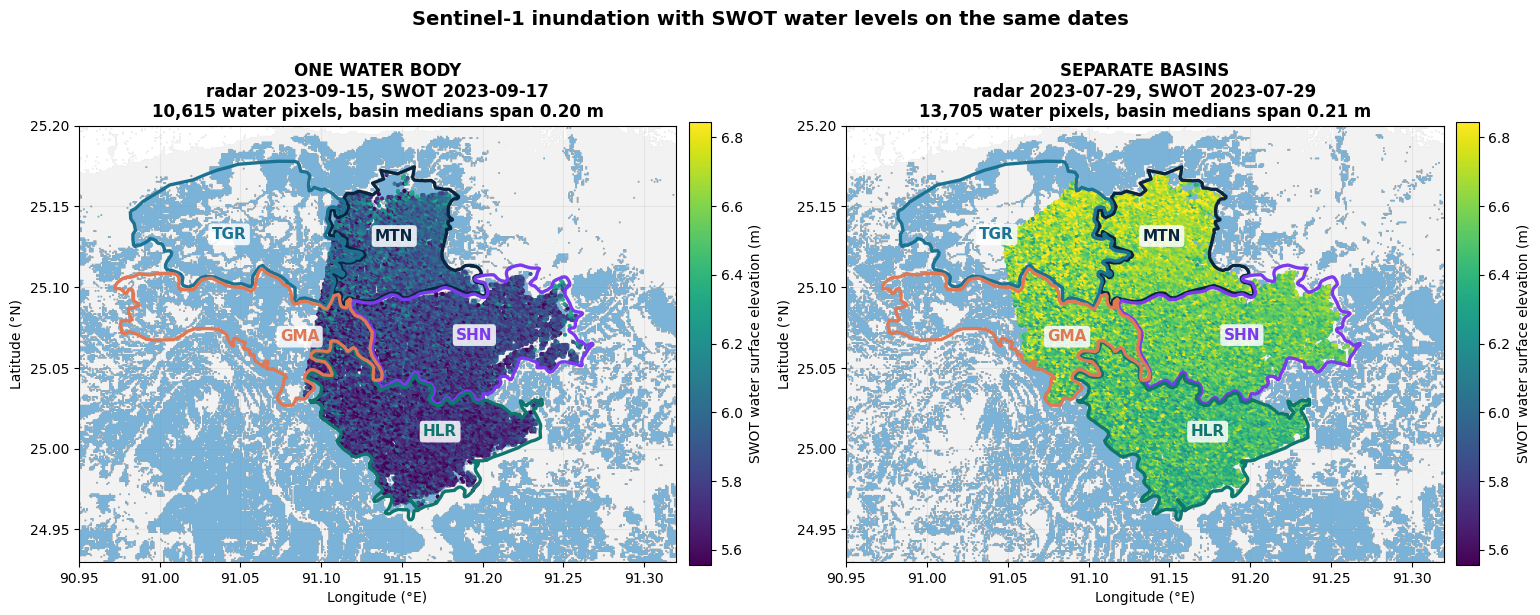

In [26]:
# %%
# ================= PART C2: the map, filtered =================
# Two fixes over the first version.
#  1. water_frac >= 0.5. The statistics used a per-basin median, which ignores
#     outliers, so water_frac > 0.01 was harmless there. A map draws every pixel,
#     and cells that are mostly land return land elevations, which is why the
#     first attempt had a 216 m colour range in a basin with 6 m of relief.
#  2. Pixels are restricted to inside the haor polygons, and the colour scale is
#     set from robust percentiles so a few survivors cannot flatten the contrast.
from matplotlib.path import Path as MplPath

WATER_FRAC_MIN = 0.5      # cell must be at least half water
UNCERT_MAX     = 1.0      # metres, tighter than the 3 m used for statistics

dates = pd.read_csv(os.path.join(ANALYSIS_ROOT, "swot_map_dates.csv"))
px_files = {}
for _, r in dates.iterrows():
    ymd = str(r["swot_date"]).replace("-", "")
    f = os.path.join(SWOT_PIXELS, f"swot_px_{r['label']}_{ymd}.csv")
    if os.path.exists(f): px_files[r["label"]] = f
    else: print(f"  missing {f}")
assert px_files, "no SWOT pixel files. Run swot_extract_pixels.py first."

def _largest(geom):
    return max(geom.geoms, key=lambda g: g.area) if geom.geom_type == "MultiPolygon" else geom
hv = haors.to_crs("EPSG:4326")
paths = {h.haor_id: MplPath(np.asarray(_largest(h.geometry).exterior.coords))
         for _, h in hv.iterrows()}

def clean(df):
    """Keep only confident water pixels lying inside a basin."""
    d = df[(df["water_frac"] >= WATER_FRAC_MIN) &
           (df["wse_uncert"] <= UNCERT_MAX)].copy()
    if not len(d): return d, {}
    pts = np.column_stack([d["lon"].values, d["lat"].values])
    inside = np.zeros(len(d), bool)
    which = np.full(len(d), "", dtype=object)
    for hid, p in paths.items():
        m = p.contains_points(pts)
        which[m & ~inside] = hid
        inside |= m
    d = d[inside].copy(); d["haor_id"] = which[inside]
    # robust outlier trim, in case a land pixel still slipped through
    lo, hi = d["wse"].quantile([0.01, 0.99])
    d = d[(d["wse"] >= lo) & (d["wse"] <= hi)]
    per = d.groupby("haor_id")["wse"].agg(["count", "median"]).round(2)
    return d, per

def band_for_date(stack_path, target_date):
    with rasterio.open(stack_path) as s:
        for i, desc in enumerate(s.descriptions):
            m = re.search(r"(20\d{2})(\d{2})(\d{2})", desc or "")
            if not m: continue
            if datetime.date(*map(int, m.groups())) == target_date:
                arr = s.read(i + 1).astype("float32")
                if s.nodata is not None: arr[arr == s.nodata] = np.nan
                return arr, plotting_extent(s)
    return None, None

year = int(dates["year"].iloc[0])
stack = os.path.join(BASE, f"flood_stack_cluster_{year}.tif")

cleaned = {}
for lbl, f in px_files.items():
    raw = pd.read_csv(f)
    d, per = clean(raw)
    cleaned[lbl] = d
    print(f"{lbl:9}: {len(raw):,} pixels -> {len(d):,} after filtering")
    if len(d):
        print(f"           wse {d['wse'].min():.2f} to {d['wse'].max():.2f} m "
              f"(spread {d['wse'].max()-d['wse'].min():.2f} m)")
        print(per.to_string())
    print()

# one shared colour scale so the two panels are comparable
allw = pd.concat([d["wse"] for d in cleaned.values() if len(d)])
vmin, vmax = allw.quantile([0.02, 0.98])
print(f"shared colour scale: {vmin:.2f} to {vmax:.2f} m")

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.6))
for ax, lbl in zip(axes, ["merged", "separate"]):
    row = dates[dates["label"] == lbl].iloc[0]
    rdate = datetime.date.fromisoformat(str(row["radar_date"]))
    arr, extent = band_for_date(stack, rdate)
    if arr is not None:
        ax.imshow(np.where(arr == 0, 1.0, np.nan), extent=extent, cmap="Greys",
                  vmin=0, vmax=3, alpha=.22, zorder=1)
        ax.imshow(np.where(arr == 1, 1.0, np.nan), extent=extent, cmap="Blues",
                  vmin=0, vmax=1.7, alpha=.75, zorder=2)
    d = cleaned.get(lbl)
    if d is not None and len(d):
        sc = ax.scatter(d["lon"], d["lat"], c=d["wse"], s=9, cmap="viridis",
                        vmin=vmin, vmax=vmax, zorder=4, edgecolors="none")
        cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
        cb.set_label("SWOT water surface elevation (m)", fontsize=10)
        med = d.groupby("haor_id")["wse"].median()
        sub = (f"{len(d):,} water pixels, basin medians span "
               f"{med.max()-med.min():.2f} m")
    else:
        sub = "no water pixels after filtering"
    for _, h in hv.iterrows():
        gpd.GeoSeries([h.geometry.boundary]).plot(
            ax=ax, color=HAOR_COLORS.get(h.haor_id, "k"), lw=2.4, zorder=5)
        pt = h.geometry.representative_point()
        ax.annotate(h.haor_id, (pt.x, pt.y), ha="center", va="center", fontsize=11,
                    fontweight="bold", color=HAOR_COLORS.get(h.haor_id, "k"), zorder=6,
                    bbox=dict(boxstyle="round,pad=0.22", fc="white", alpha=.85, lw=0))
    ax.set_title(f"{'ONE WATER BODY' if lbl=='merged' else 'SEPARATE BASINS'}\n"
                 f"radar {rdate}, SWOT {row['swot_date']}\n{sub}",
                 fontweight="bold", fontsize=12)
    ax.set_xlabel("Longitude (\u00b0E)"); ax.set_ylabel("Latitude (\u00b0N)")
    ax.set_xlim(90.95, 91.32); ax.set_ylim(24.93, 25.20)
    ax.set_aspect("equal"); ax.grid(alpha=.2)

fig.suptitle("Sentinel-1 inundation with SWOT water levels on the same dates",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_ROOT, "C_connectivity_map.png"), dpi=170,
            bbox_inches="tight")
plt.show()